# **Malaria Detection**

##<b>Problem Definition</b>
**The context:** Why is this problem important to solve?<br> Malaria is a life-threatening disease that affects nearly half of the global population. Million of cases and thousands of deaths have been reported in just one year (2019). Early diagnosis is critical but currently relies on manual inspection of red blood cell images by medical professionals, this process is time consuming, error-prone, and dependent on expert availability.
Automating this diagnosis process with computer vision can significantly improve speed, consistency and accuracy, saving lives and enabling better disease management.





**The objectives:** What is the intended goal?<br>

The goal of this project is to build a robust deep learning model that can automatically detect malaria from red blood cell images. Specifically, the model should classify images of red blood cells into one of two categories:



*   Parasitized (infected with the malaria-causing parasite)
*   Uninfected (healthy red blood cells)

This model aims to assist medical professionals in diagnosing malaria quickly and reliably.





**The key questions:** What are the key questions that need to be answered?<br>



*   Can we develop a deep learning model that accurately distinguishes between parasitized and uninfected cells?
*   What neural network architecture provides the best performance and accuracy?
* How well does the model generalize to unseen validation/test images?
* What are the performance metrics (accuracy, precision, recall, F1-score) of the model, especially in identifying parasitized cells?


**The problem formulation:** What is it that we are trying to solve using data science?

This is a binary image classification problem where the task is to classify an input image of a red blood cell into one of two classes:

* Parasitized = 1 --> Infected with malaria
* Uninfected = 0

By leveraging CNNs along with data augmentation and regularization techniques, the project aims to build an accurate and efficient tool for automated malaria diagnosis.

## <b>Data Description </b>

There are a total of 24,958 train and 2,600 test images (colored) that we have taken from microscopic images. These images are of the following categories:<br>


**Parasitized:** The parasitized cells contain the Plasmodium parasite which causes malaria<br>
**Uninfected:** The uninfected cells are free of the Plasmodium parasites<br>


###<b> Mount the Drive

In [4]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### <b>Loading libraries</b>

In [5]:
# Importing libraries required to load the data
import zipfile

import os

from PIL import Image

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler


# To ignore warnings
import warnings

warnings.filterwarnings('ignore')

# Remove the limit from the number of displayed columns and rows. It helps to see the entire dataframe while printing it
pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 200)

### <b>Let us load the data</b>

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same to your Google Drive. Then unzip the folder.

In [6]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/Colab Notebooks/Malaria Detection Deep Learning Abr 2025/cell_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:

    zip_ref.extractall()

The extracted folder has different folders for train and test data will contain the different sizes of images for parasitized and uninfected cells within the respective folder name.

The size of all images must be the same and should be converted to 4D arrays so that they can be used as an input for the convolutional neural network. Also, we need to create the labels for both types of images to be able to train and test the model.

Let's do the same for the training data first and then we will use the same code for the test data as well.

In [7]:
# Storing the path of the extracted "train" folder
train_dir = '/content/cell_images/train'

# Size of image so that each image has the same size
SIZE = 64

# Empty list to store the training images after they are converted to NumPy arrays
train_images = []

# Empty list to store the training labels (0 - uninfected, 1 - parasitized)
train_labels = []

In [8]:
# We will run the same code for "parasitized" as well as "uninfected" folders within the "train" folder
for folder_name in ['/parasitized/', '/uninfected/']:

    # Path of the folder
    images_path = os.listdir(train_dir + folder_name)

    for i, image_name in enumerate(images_path):

        try:

            # Opening each image using the path of that image
            image = Image.open(train_dir + folder_name + image_name)

            # Resizing each image to (64, 64)
            image = image.resize((SIZE, SIZE))

            # Converting images to arrays and appending that array to the empty list defined above
            train_images.append(np.array(image))

            # Creating labels for parasitized and uninfected images
            if folder_name == '/parasitized/':

                train_labels.append(1)

            else:

                train_labels.append(0)

        except Exception:

            pass

# Converting lists to arrays
train_images = np.array(train_images)

train_labels = np.array(train_labels)

In [9]:
# Storing the path of the extracted "test" folder
test_dir = '/content/cell_images/test'

# Size of image so that each image has the same size (it must be same as the train image size)
SIZE = 64

# Empty list to store the testing images after they are converted to NumPy arrays
test_images = []

# Empty list to store the testing labels (0 - uninfected, 1 - parasitized)
test_labels = []

In [10]:
# We will run the same code for "parasitized" as well as "uninfected" folders within the "test" folder
for folder_name in ['/parasitized/', '/uninfected/']:

    # Path of the folder
    images_path = os.listdir(test_dir + folder_name)

    for i, image_name in enumerate(images_path):

        try:
            # Opening each image using the path of that image
            image = Image.open(test_dir + folder_name + image_name)

            # Resizing each image to (64, 64)
            image = image.resize((SIZE, SIZE))

            # Converting images to arrays and appending that array to the empty list defined above
            test_images.append(np.array(image))

            # Creating labels for parasitized and uninfected images
            if folder_name == '/parasitized/':

                test_labels.append(1)

            else:

                test_labels.append(0)

        except Exception:

            pass

# Converting lists to arrays
test_images = np.array(test_images)

test_labels = np.array(test_labels)

###<b> Check the shape of train and test images

In [11]:
#Shape of images

print('Train Images Shape:', train_images.shape)

print('Test Images Shape:', test_images.shape)

Train Images Shape: (24958, 64, 64, 3)
Test Images Shape: (2600, 64, 64, 3)


###<b> Check the shape of train and test labels

In [12]:
# Shape of labels
print('Train Labels Shape:', train_labels.shape)

print('Test Labels Shape:', test_labels.shape)

Train Labels Shape: (24958,)
Test Labels Shape: (2600,)


####<b> Observations and insights: **_____**

Image dimensions: Both train and test images have the same dimensions (width, height, 3 color channels (RGB).

The training dataset is significantly larger than the testing data because is used to allow the model to learn patterns effectively. The testing dataset is used to evaluate the model's performance on unseen data.

The train and test labels are 1-dimensional arrays representing the class of each image (0 for uninfected, 1 for parasitized). Their shapes correspond to the number of images in each dataset.

Based on the labels' shapes, the training and testing datasets might have a roughly balanced distribution of uninfected and parasitized images. We need to plot the label distribution to further confirm this, it's important to have a balanced dataset.

### <b>Check the minimum and maximum range of pixel values for train and test images

In [13]:
# min and max function from numpy

print('Train Images Min:', np.min(train_images))

print('Train Images Max:', np.max(train_images))

print('Test Images Min:', np.min(test_images))

print('Test Images Max:', np.max(test_images))


Train Images Min: 0
Train Images Max: 255
Test Images Min: 0
Test Images Max: 255


####<b> Observations and insights: _____

The pixel values in both training and test datasets range from 0 to 255.  

This confirms that the images are stored in 8-bit color format (RGB), where 0 represent black (no intensity) and 255 represents white (full intensity).

Neural networks work best when input features are on a similar scale, this confirms the need for normalization before training.

###<b> Count the number of values in both uninfected and parasitized

In [14]:
pd.value_counts(train_labels)

pd.value_counts(test_labels)


,count
1,1300
0,1300


In [15]:
# Display the shape of the first 5 images and the first 5 labels to verify the normalization
for i in range(5):
    print(f"Shape of image {i+1}: {train_images[i].shape}")
    print(f"Label of image {i+1}: {train_labels[i]}")

Shape of image 1: (64, 64, 3)
Label of image 1: 1
Shape of image 2: (64, 64, 3)
Label of image 2: 1
Shape of image 3: (64, 64, 3)
Label of image 3: 1
Shape of image 4: (64, 64, 3)
Label of image 4: 1
Shape of image 5: (64, 64, 3)
Label of image 5: 1


###<b>Normalize the images

In [16]:
train_images = (train_images / 255.0).astype('float32')

test_images = (test_images / 255).astype('float32')


####<b> Observations and insights: _____

The data is Balanced, so that's the ideal scenario.

The images are normalized to pixel values in a range between 0 and 1.

###<b> Plot to check if the data is balanced

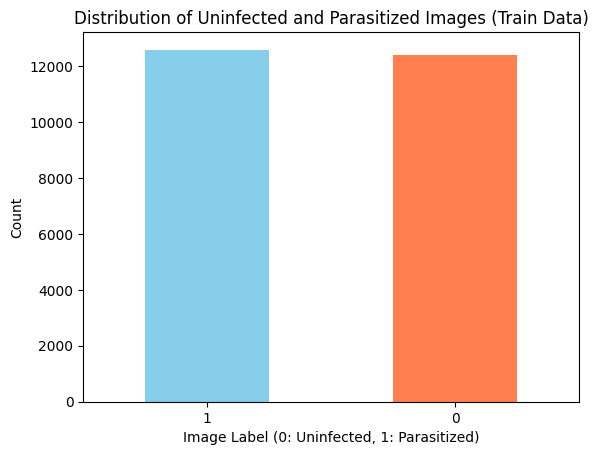

In [17]:
#Bar Plot
# Assuming 'train_labels' is your array of labels (0 or 1)
label_counts = pd.value_counts(train_labels)

# Create the bar plot
label_counts.plot(kind='bar', color=['skyblue', 'coral'])

plt.title('Distribution of Uninfected and Parasitized Images (Train Data)')
plt.xlabel('Image Label (0: Uninfected, 1: Parasitized)')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()


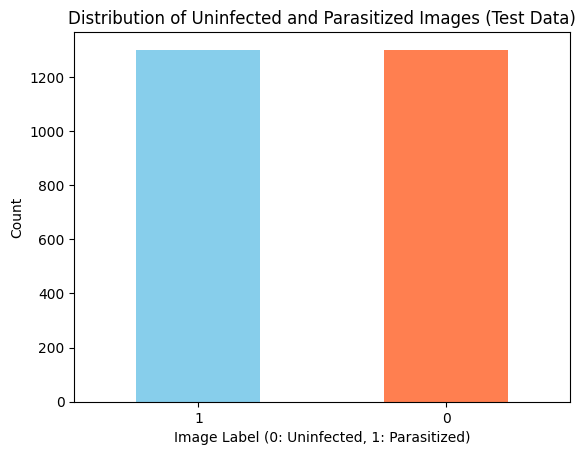

In [18]:
#Bar Plot
# Assuming 'test_labels' is your array of labels (0 or 1)
label_counts = pd.value_counts(test_labels)

# Create the bar plot
label_counts.plot(kind='bar', color=['skyblue', 'coral'])

plt.title('Distribution of Uninfected and Parasitized Images (Test Data)')
plt.xlabel('Image Label (0: Uninfected, 1: Parasitized)')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()

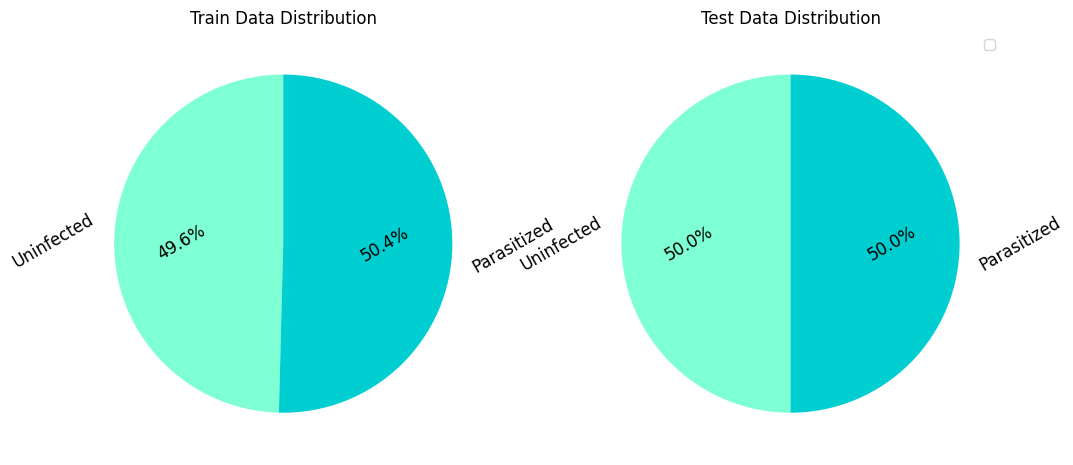

In [19]:
#pie-plot

# Assuming train_labels and test_labels are defined as in the provided code
train_counts = pd.value_counts(train_labels)
test_counts = pd.value_counts(test_labels)

labels = ['Uninfected', 'Parasitized']
sizes_train = [train_counts[0], train_counts[1]]
sizes_test = [test_counts[0], test_counts[1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#Define the colors for the slices

colors = ['aquamarine', 'darkturquoise']

#Adjust text properties

textprops = {'fontsize': 12, 'rotation' :30 }

plt.legend(labels, loc="best")

axes[0].pie(sizes_train, labels=labels, autopct='%1.1f%%', startangle=90, colors= colors, textprops = textprops)
axes[0].set_title('Train Data Distribution')

axes[1].pie(sizes_test, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops = textprops)
axes[1].set_title('Test Data Distribution')

plt.show()


<Axes: ylabel='count'>

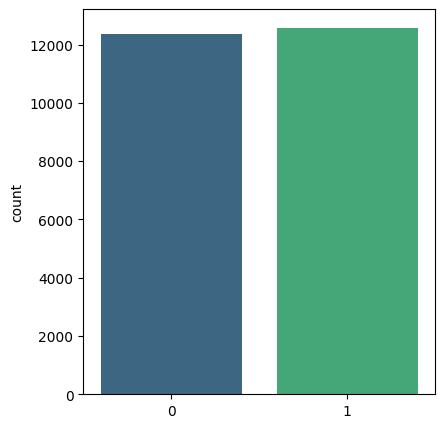

In [20]:
# Count plot

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

sns.countplot(x=train_labels, palette='viridis')

<Axes: ylabel='count'>

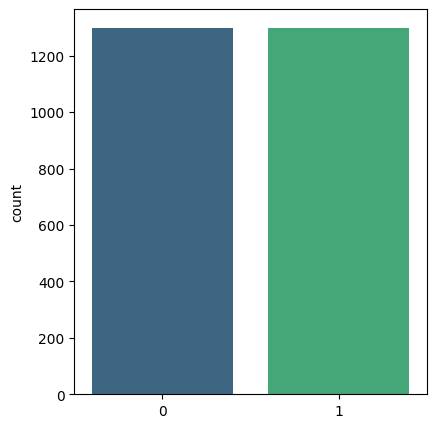

In [21]:
# Count plot

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

sns.countplot(x=test_labels, palette='viridis')

####<b> Observations and insights: _____

**Data Balance:**

Overall: The dataset demonstrates a commendable balance between the two classes, Uninfected and Parasitized, in both the training and testing sets. This balance is crucial for training a robust and unbiased model that can accurately classify both types of cells.
Training Data: The training data exhibits a slight skew towards the Parasitized class, with approximately 50.4% of the images belonging to this category. However, the difference is relatively small and should not significantly impact model training.
Testing Data: The testing data showcases a near-perfect 50-50 split between the two classes. This even distribution ensures a reliable evaluation of the model's performance on unseen data.

**Distribution:**

Train vs. Test: The slight variation in class distribution between the train and test data might be due to random sampling during data splitting. The consistency in the overall balance suggests that this minor difference is unlikely to introduce significant bias.

Favorable Dataset: The balanced nature of the dataset, along with the near-perfect 50-50 distribution in the testing data, makes it a very favorable dataset for this problem statement. This should lead to better model training and reliable performance evaluation.

### <b>Data Exploration</b>
Let's visualize the images from the train data

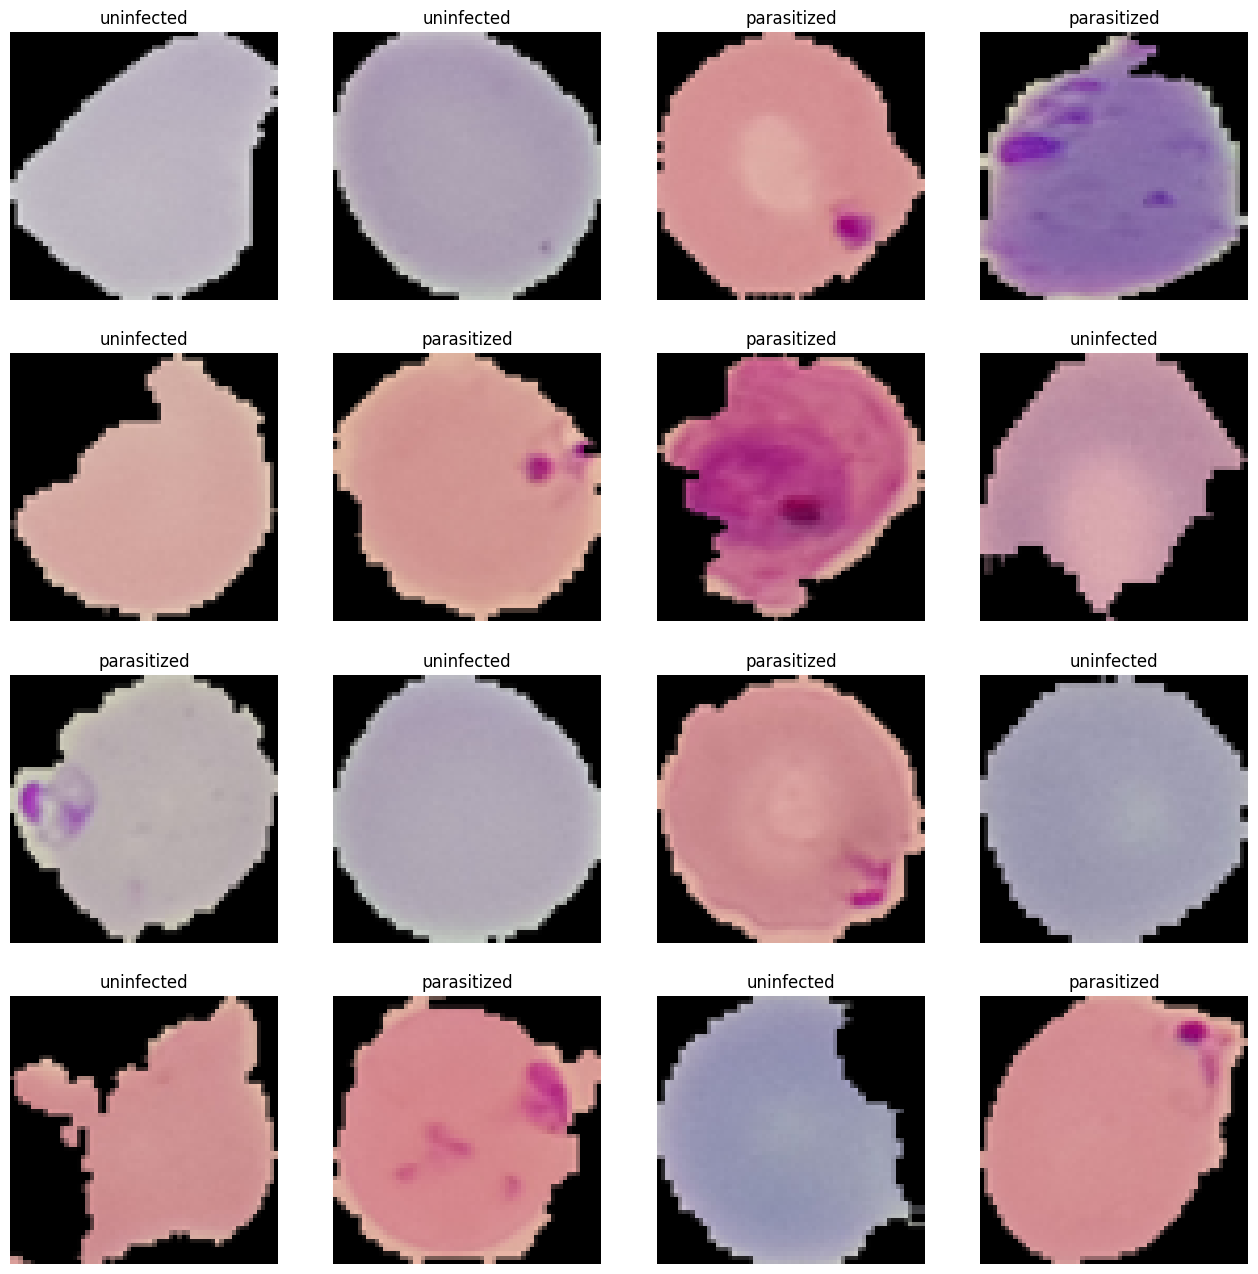

In [22]:
np.random.seed(42)

plt.figure(1, figsize = (16 , 16))

for n in range(1, 17):

    plt.subplot(4, 4, n)

    index = int(np.random.randint(0, train_images.shape[0], 1))

    if train_labels[index] == 1:

        plt.title('parasitized')

    else:
        plt.title('uninfected')

    plt.imshow(train_images[index])

    plt.axis('off')

####<b> Observations and insights: _____

Balanced Representation: The random sample appears to contain a roughly equal number of parasitized and uninfected cell images. This is a positive indication that the dataset is likely balanced overall, as the sample reflects the general distribution of the data.

Absence of Bias: The random selection process using the fixed seed has produced a sample that doesn't seem to exhibit any obvious bias towards either class. This suggests that the sampling method is effective in capturing a representative subset of the data.

Dataset Quality: Based on the visualized images, there are no immediate signs of significant data quality issues, such as corrupted images or mislabeling. However, a more thorough examination might be necessary to identify any subtle anomalies or potential challenges in the dataset.

###<b> Visualize the images with subplot(6, 6) and figsize = (12, 12)

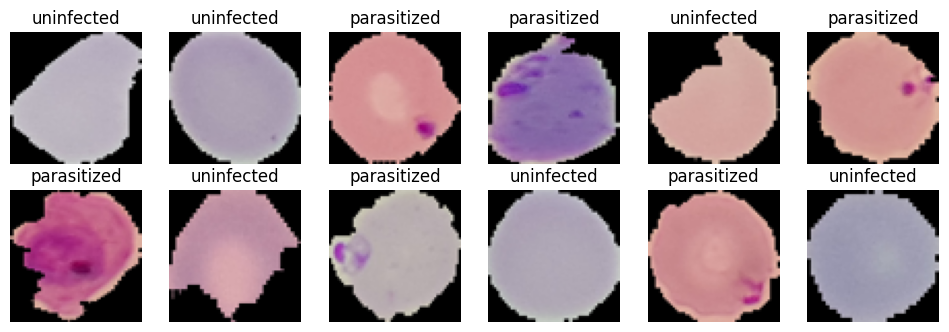

In [23]:
np.random.seed(42)

plt.figure(1, figsize = (12 , 12))

for n in range(1, 13):

    plt.subplot(6, 6, n)

    index = int(np.random.randint(0, train_images.shape[0], 1))

    if train_labels[index] == 1:

        plt.title('parasitized')

    else:
        plt.title('uninfected')

    plt.imshow(train_images[index])

    plt.axis('off')



####<b>Observations and insights:

Observations very similar to the last images.

Representative Sample: The visualized images seem to represent a fairly balanced mix of parasitized and uninfected cells. This suggests that the random sampling method, using a fixed seed for reproducibility, has effectively captured the overall distribution of the dataset.

Visual Distinctions: There are noticeable visual differences between the two classes. Parasitized cells often exhibit distinct features like the presence of the parasite (dark purple or black spots) within the red blood cells. Uninfected cells typically appear as regular, round red blood cells without any such internal structures.

Image Quality: The images generally appear to be of good quality, with clear cell structures and minimal noise or artifacts. This indicates that the dataset has been preprocessed or curated appropriately for deep learning tasks. However, a closer inspection of individual images might reveal subtle variations in image quality that could potentially affect model performance.

###<b> Plotting the mean images for parasitized and uninfected

In [24]:
# Function to find the mean
def find_mean_img(images, title):

    # Calculate the average
    mean_img = np.mean(images, axis = 0)[0]

    # Reshape it back to a matrix
    plt.imshow(mean_img)

    plt.title(f'Average {title}')

    plt.axis('off')

    plt.show()

    return mean_img


<b> Mean image for parasitized

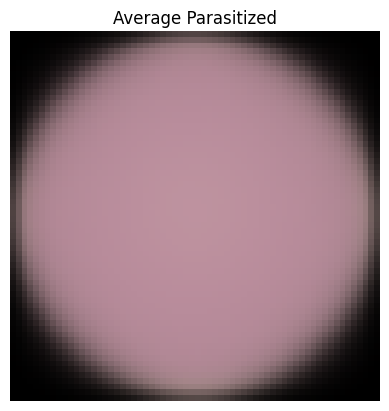

In [25]:
# If the label = 1 then the image is parasitized and if the label = 0 the the image in uninfected

parasitized_data = []  # Create a list to store the parasitized data

for img, label in zip(train_images, train_labels):

        if label == 1:

              parasitized_data.append([img])

parasitized_mean = find_mean_img(np.array(parasitized_data), 'Parasitized')   # find the mean

<b> Mean image for uninfected

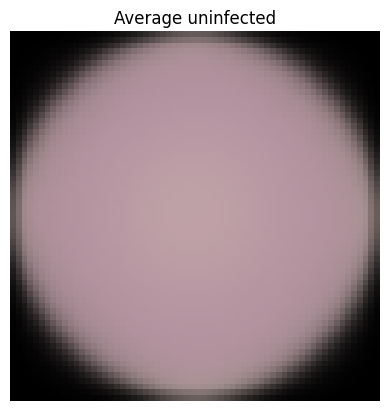

In [26]:
uninfected_data = []  # Create a list to store the uninfected data

for img, label in zip(train_images, train_labels):

        if label == 0:

              uninfected_data.append([img])

uninfected_mean = find_mean_img(np.array(uninfected_data), 'uninfected')   # find the mean



####<b> Observations and insights: _____

The mean images look similar overall, careful examination and analysis can reveal subtle differences.

### <b>Converting RGB to HSV of Images using OpenCV

###<b> Converting the train data

In [27]:
# prompt: convert the training data from RGB to HSV of Images using OpenCV

import cv2

hsv_images=[]   # to hold the HSV image array

for i in np.arange(0, 100, 1): #converting the first 100 images

  a = cv2.cvtColor(train_images[i], cv2.COLOR_BGR2HSV)

  hsv_images.append(a)

hsv_images = np.array(hsv_images)


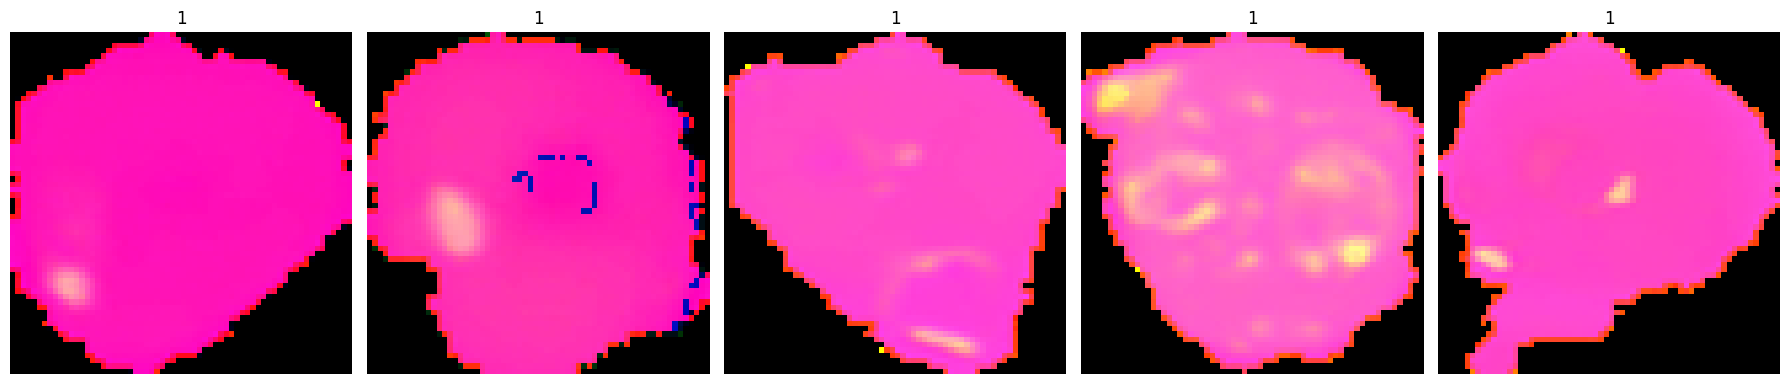

In [28]:
viewimage = np.random.randint(1, 100, 5)

fig, ax = plt.subplots(1, 5, figsize = (18, 18))

for t, i in zip(range(5), viewimage):

  Title = train_labels[i]

  ax[t].set_title(Title)

  ax[t].imshow(hsv_images[i])

  ax[t].set_axis_off()

  fig.tight_layout()

###<b> Converting the test data

In [29]:
import cv2

hsv_images=[]   # to hold the HSV image array

for i in np.arange(0, 100, 1): #converting the first 100 images

  a = cv2.cvtColor(test_images[i], cv2.COLOR_BGR2HSV)

  hsv_images.append(a)

hsv_images = np.array(hsv_images)

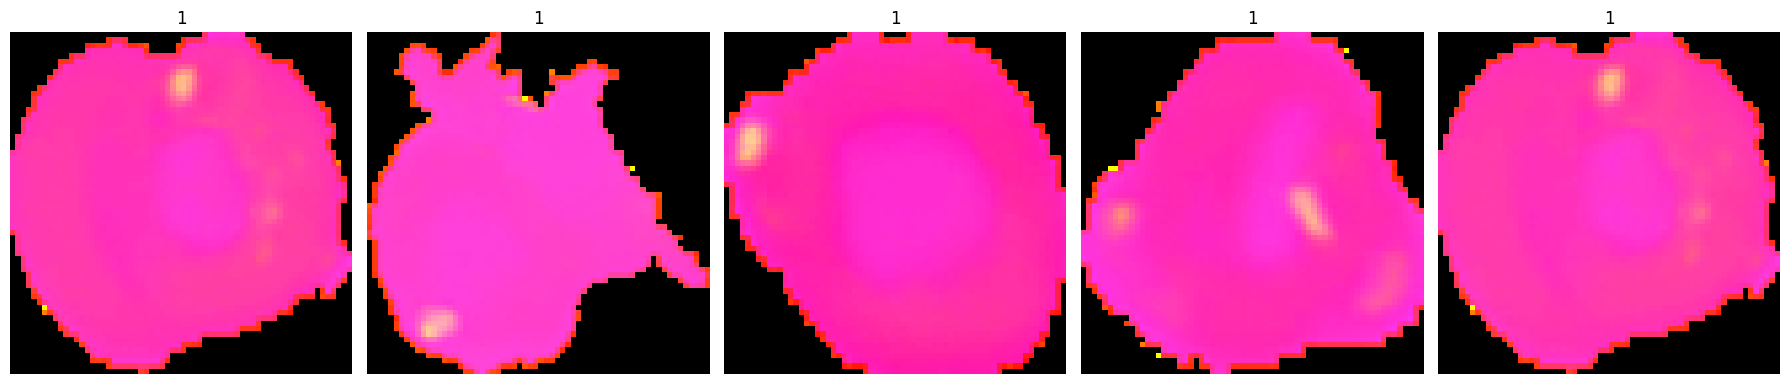

In [30]:
viewimage = np.random.randint(1, 100, 5)

fig, ax = plt.subplots(1, 5, figsize = (18, 18))

for t, i in zip(range(5), viewimage):

  Title = test_labels[i]

  ax[t].set_title(Title)

  ax[t].imshow(hsv_images[i])

  ax[t].set_axis_off()

  fig.tight_layout()

####<b>Observations and insights: _____

The HSV images array provides a potentially valuable alternative representation of the data of the malaria detection. The separated channels of hue, saturation, and value can enhance color information, improve feature extraction, and contributes to increase model accuracy.

###<b> Processing Images using Gaussian Blurring

###<b> Gaussian Blurring on train data

In [31]:
gaussian_images=[]   # to hold the Gaussian image array

for i in np.arange(0, 100, 1): #converting the first 100 images

  a = cv2.GaussianBlur(train_images[i], (5, 5), 0)
  gaussian_images.append(a)

gaussian_images = np.array(gaussian_images)

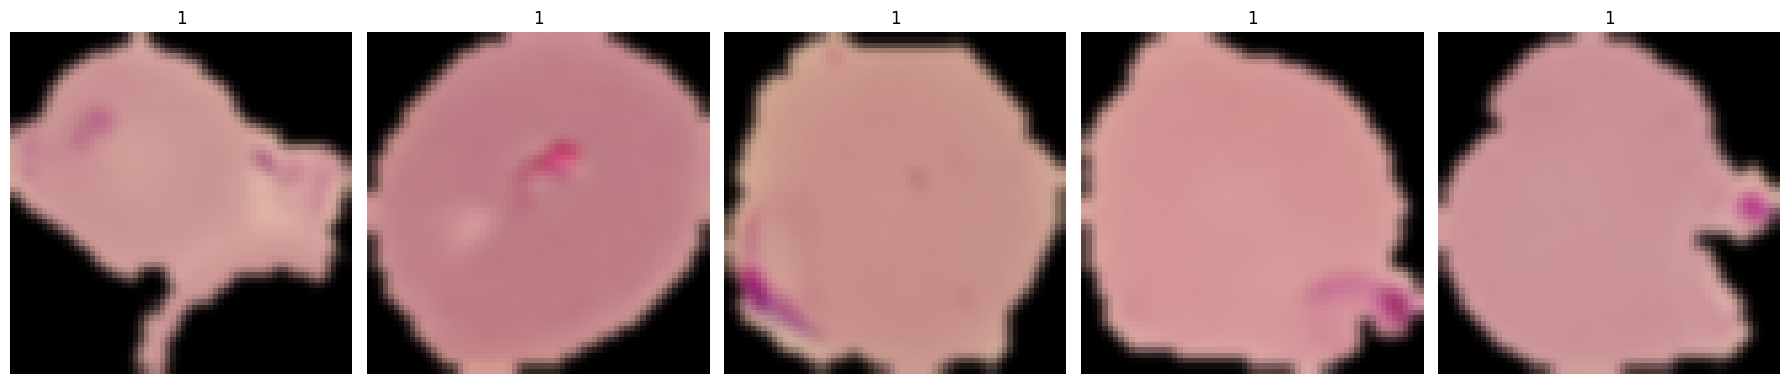

In [32]:
viewblurredimage = np.random.randint(1, 100, 5)

fig, ax = plt.subplots(1, 5, figsize = (18, 18))

for t, i in zip(range(5), viewblurredimage):
  Title = train_labels[i]
  ax[t].set_title(Title)
  ax[t].imshow(gaussian_images[i])
  ax[t].set_axis_off()
  fig.tight_layout()

###<b> Gaussian Blurring on test data

In [33]:
gaussian_images=[]   # to hold the Gaussian image array

for i in np.arange(0, 100, 1): #converting the first 100 images

  a = cv2.GaussianBlur(test_images[i], (5, 5), 0)
  gaussian_images.append(a)

gaussian_images = np.array(gaussian_images)

####**Observations and insights: _____**

**Think About It:** Would blurring help us for this problem statement in any way? What else can we try?

Gaussian blurring is unlikely to have significantly helped improve the performance of the malaria detection model.

Preserving fine details and enhancing the visual cues related to the parasite are more crucial for accurate classification, and other image processing techniques might be more suitable.

Alternative Approaches: sharpening, contrast enhancement, edge detection.

## **Model Building**

### **Base Model**

**Note:** The Base Model has been fully built and evaluated with all outputs shown to give an idea about the process of the creation and evaluation of the performance of a CNN architecture. A similar process can be followed in iterating to build better-performing CNN architectures.

###<b> Importing the required libraries for building and training our Model

In [34]:

#Clearing backend

from tensorflow.keras import backend

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization

from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.layers import LeakyReLU # Import LeakyReLU

from random import shuffle

backend.clear_session()

# Fixing the seed for random number generators so that we can ensure we receive the same output everytime

np.random.seed(42)

import random

random.seed(42)

tf.random.set_seed(42)

####<B>One Hot Encoding the train and test labels

In [35]:

train_labels = to_categorical(train_labels, num_classes = 2)

test_labels = to_categorical(test_labels, num_classes = 2)

###<b> Building the model

In [36]:
#Creating sequential model
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size= 2, activation='relu',padding = "same", input_shape=(64, 64, 3)))  # Input shape matches your image size

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.2))

model.add(Conv2D(filters = 32, kernel_size= 2, padding = 'same', activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.2))

model.add(Conv2D(filters = 32, kernel_size= 2, padding = 'same', activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(512, activation='relu'))

model.add(Dropout(0.4))

model.add(Dense(2, activation='softmax'))  # Output layer with 2 classes (parasitized/uninfected)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,058,786 (4.04 MB)

 Trainable params: 1,058,786 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

###<b> Compiling the model

In [37]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])



<b> Using Callbacks

In [38]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2),  # Stop training early if validation loss doesn't improve for 2 epochs
    ModelCheckpoint('.mdl.wts.keras', monitor='val_loss', save_best_only=True)  # Save the best model based on validation loss
]

<b> Fit and train our Model

In [39]:
history = model.fit(
    train_images, train_labels,
    epochs=20,  # Adjust the number of epochs as needed
    batch_size=32,  # Adjust the batch size as needed
    validation_split = 0.2,
    callbacks=callbacks,  # Pass the callbacks list
    verbose = 1
)

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.7091 - loss: 0.5459 - val_accuracy: 0.9060 - val_loss: 0.1739
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9526 - loss: 0.1281 - val_accuracy: 0.9766 - val_loss: 0.1140
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9676 - loss: 0.1044 - val_accuracy: 0.9858 - val_loss: 0.1120
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9741 - loss: 0.0822 - val_accuracy: 0.9888 - val_loss: 0.0537
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9761 - loss: 0.0738 - val_accuracy: 0.9876 - val_loss: 0.0572
Epoch 6/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9773 - loss: 0.0651 - val_accuracy: 0.9844 - val_loss: 0.0581


###<b> Evaluating the model on test data

In [40]:
accuracy = model.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:-', accuracy[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9836 - loss: 0.0474

 Test_Accuracy:- 0.9830769300460815


<b> Plotting the confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1300
           1       0.99      0.98      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



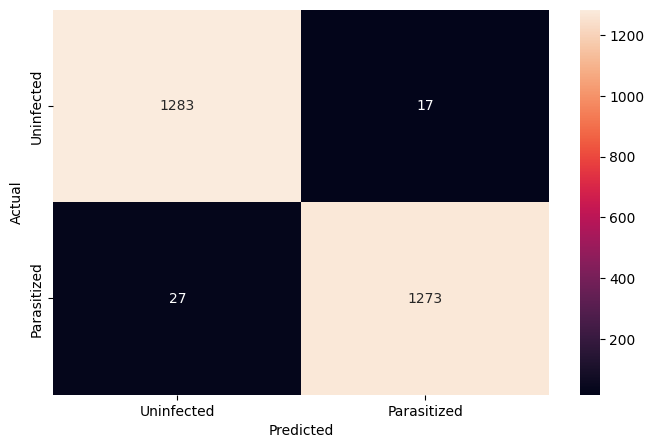

In [41]:
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

pred = model.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
print(classification_report(y_true, pred))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize = (8, 5))

sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['Uninfected', 'Parasitized'], yticklabels = ['Uninfected', 'Parasitized'])

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.show()

<b>Plotting the train and validation curves

In [42]:
# Function to plot train and validation accuracy
def plot_accuracy(history):

    N = len(history.history["accuracy"])

    plt.figure(figsize = (7, 7))

    plt.plot(np.arange(0, N), history.history["accuracy"], label = "train_accuracy", ls = '--')

    plt.plot(np.arange(0, N), history.history["val_accuracy"], label = "val_accuracy", ls = '--')

    plt.title("Accuracy vs Epoch")

    plt.xlabel("Epochs")

    plt.ylabel("Accuracy")

    plt.legend(loc="upper left")

The accuracy plot demonstrates strong model performance, with both training and validation accuracy improving rapidly in the initial epochs. By epoch 3, the model reaches a high accuracy level (around 97–99%), and both curves stabilize. Notably, validation accuracy consistently remains slightly above training accuracy, indicating excellent generalization and no signs of overfitting. This suggests that the model is not only learning effectively from the training data but also performing reliably on unseen data, making it a well-balanced and robust solution for digit classification.

So now let's try to build another model with few more add on layers and try to check if we can try to improve the model. Therefore try to build a model by adding few layers if required and altering the activation functions.

###<b> Model 1
####<b> Trying to improve the performance of our model by adding new layers


In [43]:
backend.clear_session() #Clearing the backend for a new model

###<b> Building the Model

In [44]:


# Creating sequential model

model1 = Sequential()

# First Conv Block

model1.add(Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1) , input_shape = (64, 64, 3)))

model1.add(MaxPooling2D(pool_size = 2))

model1.add(Dropout(0.2))


# Second Conv Block

model1.add(Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1)))

model1.add(MaxPooling2D(pool_size = 2))

model1.add(Dropout(0.2))


# Third Conv Block
model1.add(Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1)))

model1.add(MaxPooling2D(pool_size = 2))

model1.add(Dropout(0.2))

# Extra Conv Layer (Improvement)

model1.add(Conv2D(filters = 64, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1)))

model1.add(MaxPooling2D(pool_size = 2))

model1.add(Dropout(0.2))

#Flatten + Dense

model1.add(Flatten())

model1.add(Dense(512, activation = LeakyReLU(alpha=0.1)))

model1.add(Dropout(0.4))

#Extra Dense Layer

model1.add(Dense(256, activation = LeakyReLU(alpha=0.1)))

#Output

model1.add(Dense(2, activation = "softmax")) # 2 represents output layer neurons

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,570 (2.57 MB)

 Trainable params: 673,570 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

###<b> Compiling the model

In [45]:
model1.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

<b> Using Callbacks

In [46]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2),  # Stop training early if validation loss doesn't improve for 2 epochs
    ModelCheckpoint('.mdl.wts.keras', monitor='val_loss', save_best_only=True)  # Save the best model based on validation loss
]

<b>Fit and Train the model

In [47]:
history = model1.fit(train_images, train_labels, batch_size = 32, callbacks = callbacks, validation_split = 0.2, epochs = 20, verbose = 1)

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7875 - loss: 0.4135 - val_accuracy: 0.9830 - val_loss: 0.0593
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9724 - loss: 0.0824 - val_accuracy: 0.9796 - val_loss: 0.0511
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9759 - loss: 0.0773 - val_accuracy: 0.9856 - val_loss: 0.0392
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9778 - loss: 0.0689 - val_accuracy: 0.9760 - val_loss: 0.0573
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9777 - loss: 0.0678 - val_accuracy: 0.9732 - val_loss: 0.0624


###<b> Evaluating the model

In [48]:
accuracy = model1.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:-', accuracy[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9889 - loss: 0.0390

 Test_Accuracy:- 0.9784615635871887


<b> Plotting the confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1300
           1       0.97      0.99      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



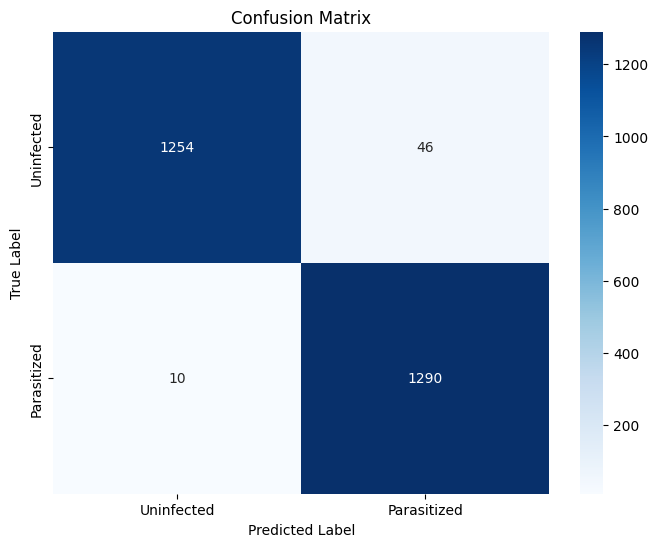

In [49]:
pred = model1.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
print(classification_report(y_true, pred))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Uninfected', 'Parasitized'],
               yticklabels=['Uninfected', 'Parasitized'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

<b> Plotting the train and the validation curves

In [50]:
# Function to plot train and validation accuracy
def plot_accuracy(history):

    N = len(history.history["accuracy"])

    plt.figure(figsize = (7, 7))

    plt.plot(np.arange(0, N), history.history["accuracy"], label = "train_accuracy", ls = '--')

    plt.plot(np.arange(0, N), history.history["val_accuracy"], label = "val_accuracy", ls = '--')

    plt.title("Accuracy vs Epoch")

    plt.xlabel("Epochs")

    plt.ylabel("Accuracy")

    plt.legend(loc="upper left")

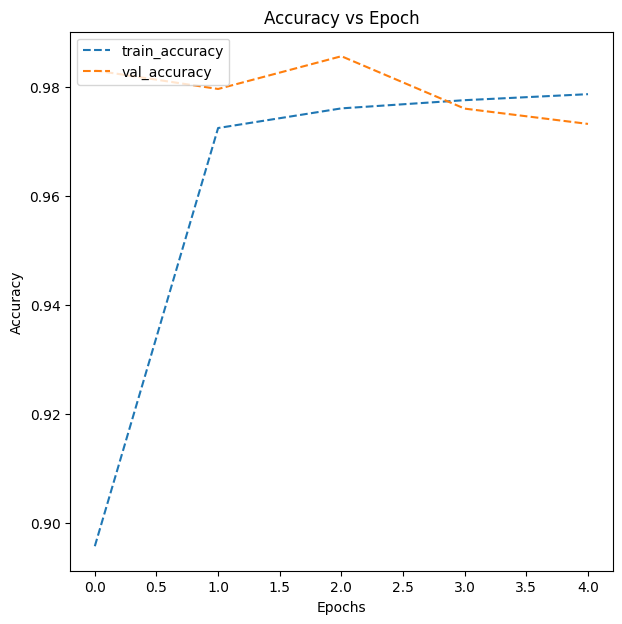

In [51]:
plot_accuracy(history)

**Observations and Insights:**

The model shows slightly more error on uninfected samples, but overall, both classes are handled with strong balance and minimal bias.

Training accuracy improves consitently, reaching close to 97.5% by epoch 2.
Validation accuracy starts high (99%) but slightly declines to (98%), indicating early signs of overfitting, the model performs slightly worse on unseen data as training progresses.

###<b>Think about it:</b><br>
Now let's build a model with LeakyRelu as the activation function  

*  Can the model performance be improved if we change our activation function to LeakyRelu?
*  Can BatchNormalization improve our model?

Let us try to build a model using BatchNormalization and using LeakyRelu as our activation function.

###<b> Model 2 with Batch Normalization

In [52]:
backend.clear_session() # Clearing the backend for new model

###<b> Building the Model

In [53]:
from tensorflow.keras import layers, models, optimizers


# Creating sequential model
model2 = Sequential()

# First Conv Block
model2.add(layers.Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = LeakyReLU(alpha=0.1), input_shape = (64, 64, 3)))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D(pool_size = 2))
model2.add(layers.Dropout(0.2))

#Second Conv Block

model2.add(layers.Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1)))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D(pool_size = 2))
model2.add(layers.Dropout(0.2))

#Third Conv Block

model2.add(layers.Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1)))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D(pool_size = 2))
model2.add(layers.Dropout(0.2))

# Flatten + Dense
model2.add(Flatten())
model2.add(Dense(512, activation = LeakyReLU(alpha=0.1)))
model2.add(layers.BatchNormalization())
model2.add(Dropout(0.4))

# Output
model2.add(Dense(2, activation = "softmax")) # 2 represents output layer neurons



model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061,698 (4.05 MB)

 Trainable params: 1,060,482 (4.05 MB)

 Non-trainable params: 1,216 (4.75 KB)

###<b>Compiling the model

In [54]:
#Compile the model
adam = optimizers.Adam(learning_rate = 0.001)
model2.compile(loss = 'binary_crossentropy', optimizer = adam, metrics = ['accuracy'])

<b> Using callbacks

In [55]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2),  # Stop training early if validation loss doesn't improve for 2 epochs
    ModelCheckpoint('.mdl.wts.keras', monitor='val_loss', save_best_only=True)  # Save the best model based on validation loss
]

<b>Fit and train the model

In [56]:
history2 = model2.fit(train_images, train_labels, batch_size = 32, callbacks = callbacks, validation_split = 0.2, epochs = 20, verbose = 1)

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6825 - loss: 0.7223 - val_accuracy: 0.9996 - val_loss: 0.0078
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9323 - loss: 0.1916 - val_accuracy: 0.9950 - val_loss: 0.0153
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9559 - loss: 0.1315 - val_accuracy: 0.9970 - val_loss: 0.0082


<b>Plotting the train and validation accuracy

In [57]:
# Function to plot train and validation accuracy
def plot_accuracy(history):

    N = len(history.history["accuracy"])

    plt.figure(figsize = (7, 7))

    plt.plot(np.arange(0, N), history.history["accuracy"], label = "train_accuracy", ls = '--')

    plt.plot(np.arange(0, N), history.history["val_accuracy"], label = "val_accuracy", ls = '--')

    plt.title("Accuracy vs Epoch")

    plt.xlabel("Epochs")

    plt.ylabel("Accuracy")

    plt.legend(loc="upper left")


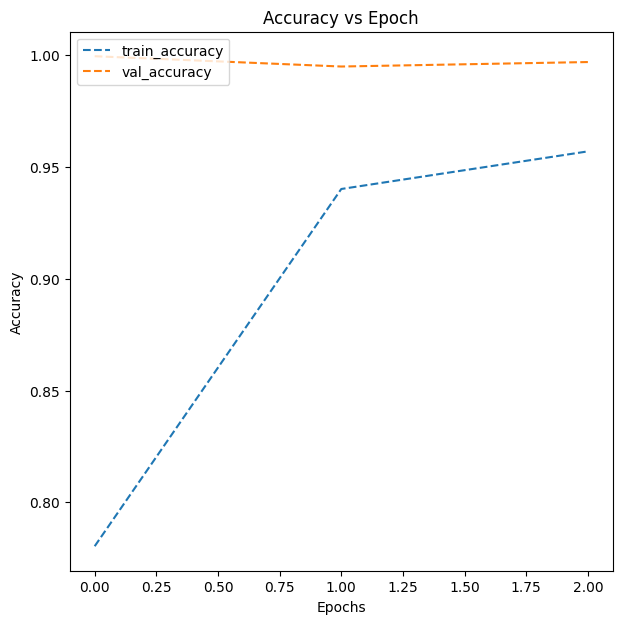

In [58]:
plot_accuracy(history2)

###<b>Evaluating the model

In [59]:
# Evaluate the model to calculate the accuracy

accuracy = model2.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:-', accuracy[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8833 - loss: 0.4480

 Test_Accuracy:- 0.9253846406936646


####<b>Observations and insights: ____

Both training and validation accuracy rise very quickly within the first few epochs, indicating the model is learning fast.

From around epoch 2 onward, validation accuracy is slightly higher than training accuracy, peaking near 100%.

This suggests the model may be performing beeter on validation than training accuracy, which can be caused by the validation data being easier than the training set.

The validation line flattens out at 100% showing the model is likely not overfitting, and generalization is very strong.

<b> Generate the classification report and confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1300
           1       0.99      0.86      0.92      1300

    accuracy                           0.93      2600
   macro avg       0.93      0.93      0.93      2600
weighted avg       0.93      0.93      0.93      2600



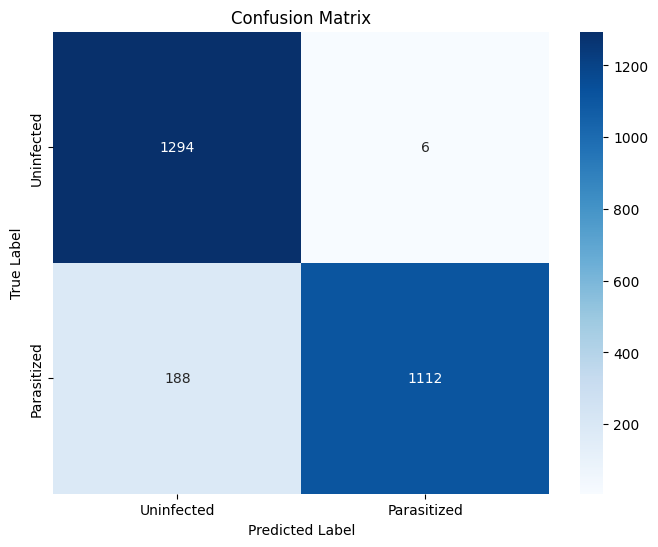

In [60]:
pred = model2.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
print(classification_report(y_true, pred))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Uninfected', 'Parasitized'],
               yticklabels=['Uninfected', 'Parasitized'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The model is very accurate in predicting both cases, especially for Uninfected cells with only 9 misclassifications.

Slight Bias Toward "Uninfected": The model misclassifies more parasitized cells than unifected ones. Recall needs to be improved for parasitized detection, which is critical in medical use cases.

###**Think About It :**<br>

* Can we improve the model with Image Data Augmentation?
* References to image data augmentation can be seen below:
  *   [Image Augmentation for Computer Vision](https://www.mygreatlearning.com/blog/understanding-data-augmentation/)
  *   [How to Configure Image Data Augmentation in Keras?](https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/)





###<b>Model 3 with Data Augmentation

In [61]:
backend.clear_session() # Clearing backend for new model

###<b> Use image data generator

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size = 0.2, random_state = 42)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Using ImageDataGenerator to generate images
train_datagen = ImageDataGenerator(horizontal_flip = True,
                                  zoom_range = 0.5, rotation_range = 30)

val_datagen  = ImageDataGenerator()

# Flowing training images using train_datagen generator
train_generator = train_datagen.flow(x = X_train, y = y_train, batch_size = 64, seed = 42, shuffle = True)


# Flowing validation images using val_datagen generator
val_generator =  val_datagen.flow(x = X_val, y = y_val, batch_size = 64, seed = 42, shuffle = True)

###**Think About It :**<br>

*  Check if the performance of the model can be improved by changing different parameters in the ImageDataGenerator.



####<B>Visualizing Augmented images

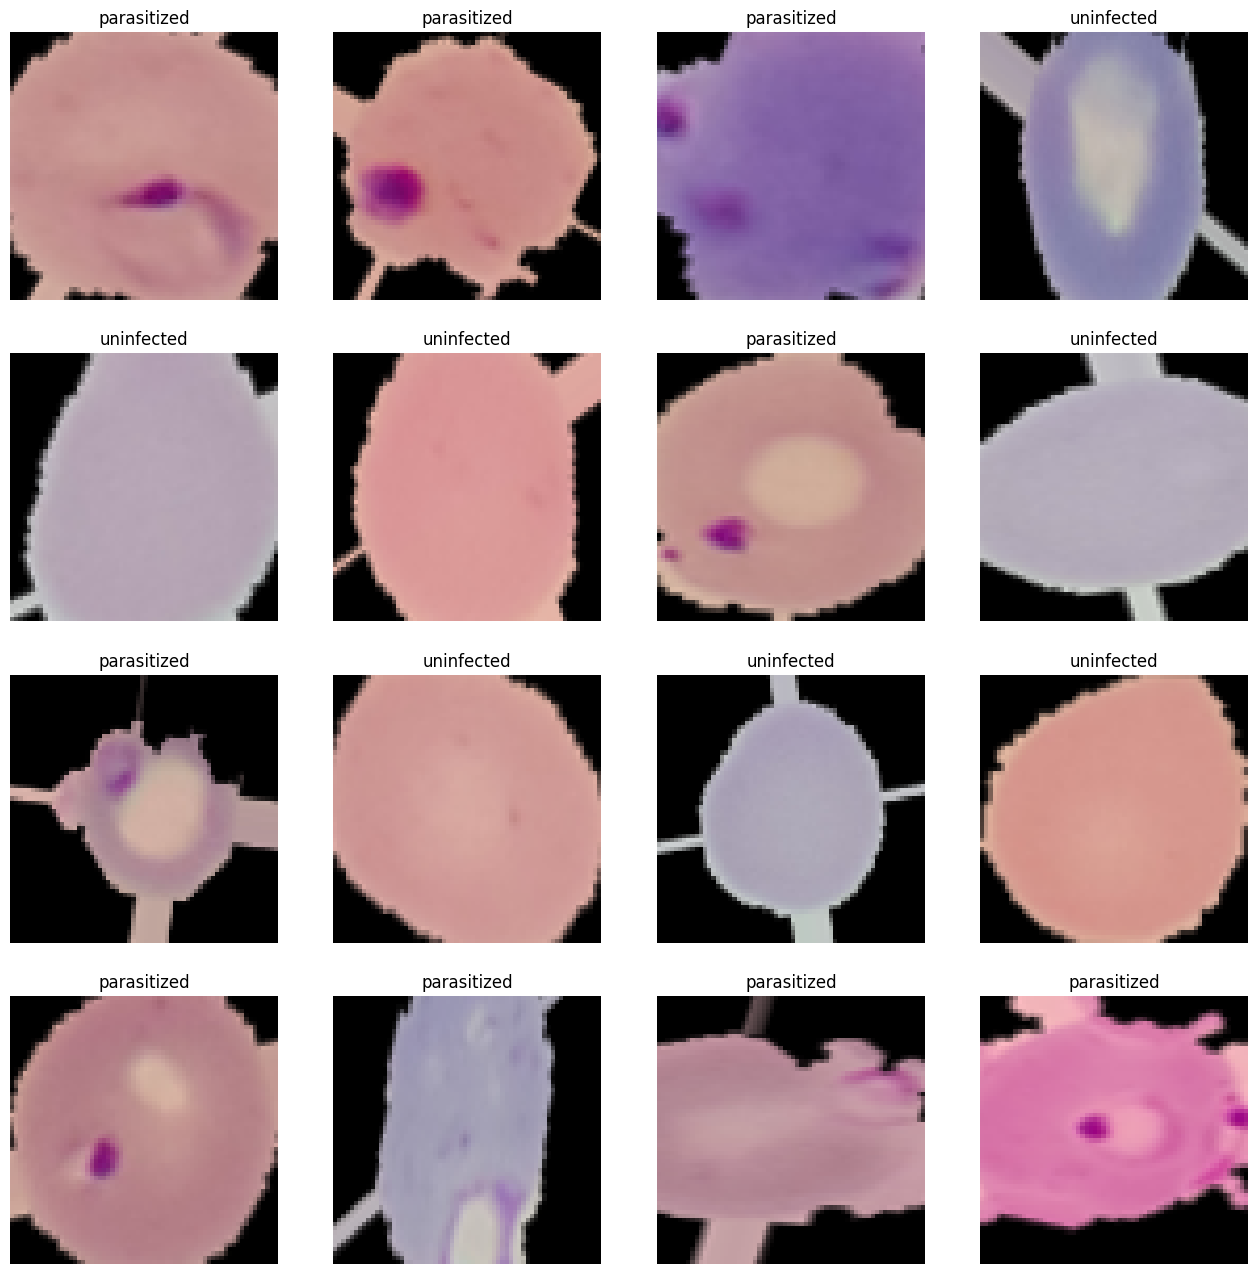

In [63]:
# Creating an iterable for images and labels from the training data
images, labels = next(train_generator)

# Plotting 16 images from the training data
fig, axes = plt.subplots(4, 4, figsize = (16, 8))

fig.set_size_inches(16, 16)
for (image, label, ax) in zip(images, labels, axes.flatten()):

    ax.imshow(image)

    if label[1] == 1:

        ax.set_title('parasitized')

    else:

        ax.set_title('uninfected')

    ax.axis('off')

####<b>Observations and insights: ____

Data Augmentation Techniques Applied:


*   Rotation
*   Horizontal flip
* Zoom

Impact on cell apperance:

* Parasite Visbility: augmentations can affect the visibility and perceived shape of the parasites. Rotation and zoom might bring the parasite into clearer view or alter its apparent form.
* Cell Structure: The overall structure and morphology of the red blood cells might be slighty distorted due to zoom or rotation.

By training on a more diverse dataset the model becomes more robust and less sensitive to variations in cell appearance, orientation and image quality.

The model is better equipped to handle unseen data, leading to improve accuracy and performance on real-world malaria detection tasks.



###<b>Building the Model

In [64]:
# Creating sequential model
from tensorflow.keras.layers import GlobalAveragePooling2D # Import GlobalAveragePooling2D
model3 = Sequential()

# First Conv Block
model3.add(layers.BatchNormalization())
model3.add(layers.Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = LeakyReLU(alpha=0.1), input_shape = (64, 64, 3)))
model3.add(layers.MaxPooling2D(pool_size = 2))
model3.add(layers.Dropout(0.2))

#Second Conv Block

model3.add(layers.Conv2D(filters = 64, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1)))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D(pool_size = 2))
model3.add(layers.Dropout(0.3))

#Third Conv Block

model3.add(layers.Conv2D(filters = 128, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1)))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D(pool_size = 2))
model3.add(layers.Dropout(0.3))

#Fourth Conv Block (New)

model3.add(layers.Conv2D(filters = 128, kernel_size = 2, padding = "same", activation = LeakyReLU(alpha=0.1)))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D(pool_size = 2))
model3.add(layers.Dropout(0.4))

# Global Average Pooling Instead of Flatten

model3.add(GlobalAveragePooling2D())

#Fully Connected Layers

model3.add(Dense(256, activation = LeakyReLU(alpha=0.1)))
model3.add(layers.BatchNormalization())
model3.add(Dropout(0.5))

# Output
model3.add(Dense(2, activation = "softmax")) # 2 represents output layer neurons



model3.summary()




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Compiling the model

adam = optimizers.Adam(learning_rate = 0.001)
model3.compile(loss = 'binary_crossentropy', optimizer = adam, metrics = ['accuracy'])

<b>Using Callbacks

In [63]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2),  # Stop training early if validation loss doesn't improve for 2 epochs
    ModelCheckpoint('.mdl.wts.keras', monitor='val_loss', save_best_only=True)  # Save the best model based on validation loss
]

<b> Fit and Train the model

In [64]:
history3 = model3.fit(train_generator,
                                  validation_data = val_generator,
                                  batch_size = 32, callbacks = callbacks,
                                  epochs = 20, verbose = 1)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.6581 - loss: 0.7461 - val_accuracy: 0.7384 - val_loss: 0.4991
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9062 - loss: 0.2674 - val_accuracy: 0.9720 - val_loss: 0.0924
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9360 - loss: 0.1932 - val_accuracy: 0.9788 - val_loss: 0.0752
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9425 - loss: 0.1715 - val_accuracy: 0.9772 - val_loss: 0.0679
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9431 - loss: 0.1725 - val_accuracy: 0.9782 - val_loss: 0.0741
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9493 - loss: 0.1547 - val_accuracy: 0.9784 - val_loss: 0.0648
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9496 - loss: 0.1598 - val_accuracy: 0.9806 - val_loss: 0.0617
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9516 - loss: 0.1486 -

###<B>Evaluating the model

<b>Plot the train and validation accuracy

In [65]:
# Function to plot train and validation accuracy
def plot_accuracy(history):

    N = len(history.history["accuracy"])

    plt.figure(figsize = (7, 7))

    plt.plot(np.arange(0, N), history.history["accuracy"], label = "train_accuracy", ls = '--')

    plt.plot(np.arange(0, N), history.history["val_accuracy"], label = "val_accuracy", ls = '--')

    plt.title("Accuracy vs Epoch")

    plt.xlabel("Epochs")

    plt.ylabel("Accuracy")

    plt.legend(loc="upper left")

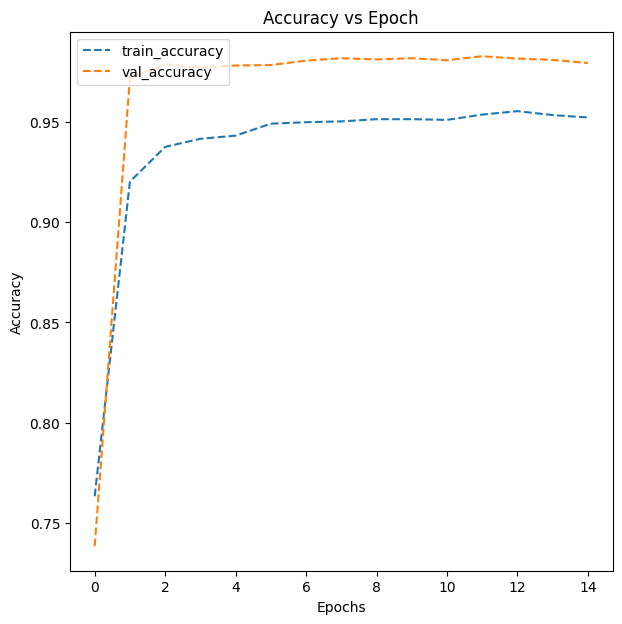

In [66]:
plot_accuracy(history3)

In [67]:
# Evaluate the model to calculate the accuracy

accuracy = model3.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:-', accuracy[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9900 - loss: 0.0364

 Test_Accuracy:- 0.9803845882415771


<B>Plotting the classification report and confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1300
           1       0.97      0.99      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



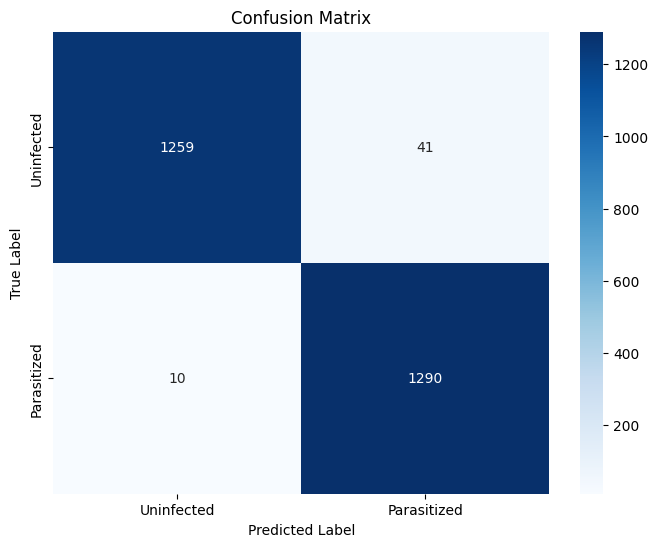

In [68]:
pred = model3.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
print(classification_report(y_true, pred))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Uninfected', 'Parasitized'],
               yticklabels=['Uninfected', 'Parasitized'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Observations and insights**

Training accuracy steadily increases, peaking aroung 95.4%, the model is learning effectively over time.

Validation accuracy rises and stabilizes around 97.8%, suggesting excellent generalization and no signs of overfitting.

We are getting lower false negatives, which are really important in medical diagnosis, as missing an infected case can have serious consequences.

<b> Now, let us try to use a pretrained model like VGG16 and check how it performs on our data.

### **Pre-trained model (VGG16)**
- Import VGG16 network upto any layer you choose
- Add Fully Connected Layers on top of it

In [69]:
# Clearing backend
from tensorflow.keras import backend

backend.clear_session()

# Fixing the seed for random number generators
np.random.seed(42)

import random

random.seed(42)

tf.random.set_seed(42)

In [70]:
from tensorflow.keras.applications.vgg16 import VGG16

from tensorflow.keras import Model

vgg = VGG16(include_top = False, weights = 'imagenet', input_shape = (64, 64, 3))

vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Unfreeze the last convolutional block for fine-tuning
for layer in vgg.layers[:-4]:  # Freeze all layers except the last 4
    layer.trainable = False

# Transfer layer
transfer_layer = vgg.get_layer('block5_pool')


# Add custom classification layers
x = Flatten()(transfer_layer.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
pred = Dense(2, activation='softmax')(x)  # Output for binary classification (2 classes)

# Build model
model4 = Model(inputs=vgg.input, outputs=pred)
model4.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,977,730 (57.14 MB)

 Trainable params: 262,786 (1.00 MB)

 Non-trainable params: 14,714,944 (56.13 MB)

###<b>Compiling the model

In [89]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

<b> using callbacks

In [90]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_vgg16_malaria_model.keras', monitor='val_loss', save_best_only=True)
]

<b>Fit and Train the model

In [91]:
# Fit the model
history4 = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=15,
                    batch_size=32,
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 30s 82ms/step - accuracy: 0.9513 - loss: 0.1439 - val_accuracy: 0.9842 - val_loss: 0.0530
Epoch 2/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9493 - loss: 0.1464 - val_accuracy: 0.9840 - val_loss: 0.0521
Epoch 3/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9528 - loss: 0.1417 - val_accuracy: 0.9840 - val_loss: 0.0507
Epoch 4/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9507 - loss: 0.1428 - val_accuracy: 0.9834 - val_loss: 0.0502
Epoch 5/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9532 - loss: 0.1398 - val_accuracy: 0.9834 - val_loss: 0.0498
Epoch 6/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9526 - loss: 0.1402 - val_accuracy: 0.9840 - val_loss: 0.0493
Epoch 7/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9510 - loss: 0.1407 - val_accuracy: 0.9836 - val_loss: 0.0493
Epoch 8/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9555 - loss: 0.1335 - 

<b>Plot the train and validation accuracy

In [92]:
# Function to plot train and validation accuracy
def plot_accuracy(history):

    N = len(history.history["accuracy"])

    plt.figure(figsize = (7, 7))

    plt.plot(np.arange(0, N), history.history["accuracy"], label = "train_accuracy", ls = '--')

    plt.plot(np.arange(0, N), history.history["val_accuracy"], label = "val_accuracy", ls = '--')

    plt.title("Accuracy vs Epoch")

    plt.xlabel("Epochs")

    plt.ylabel("Accuracy")

    plt.legend(loc="upper left")

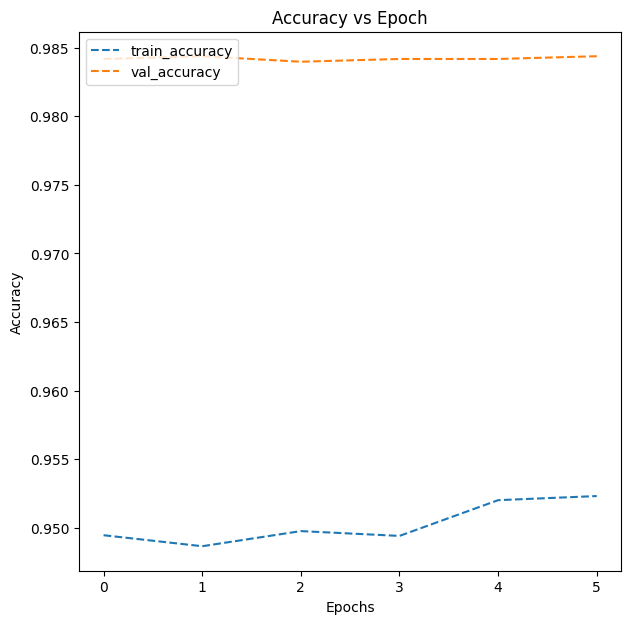

In [85]:
plot_accuracy(history4)

###**Observations and insights: _____**

*   What can be observed from the validation and train curves?

###<b> Evaluating the model

In [94]:
accuracy = model.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:-', accuracy[1])


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9849 - loss: 0.0388

 Test_Accuracy:- 0.9834615588188171


<b>Plotting the classification report and confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
              precision    recall  f1-score   support

           0       0.85      0.99      0.92      1300
           1       0.99      0.83      0.90      1300

    accuracy                           0.91      2600
   macro avg       0.92      0.91      0.91      2600
weighted avg       0.92      0.91      0.91      2600



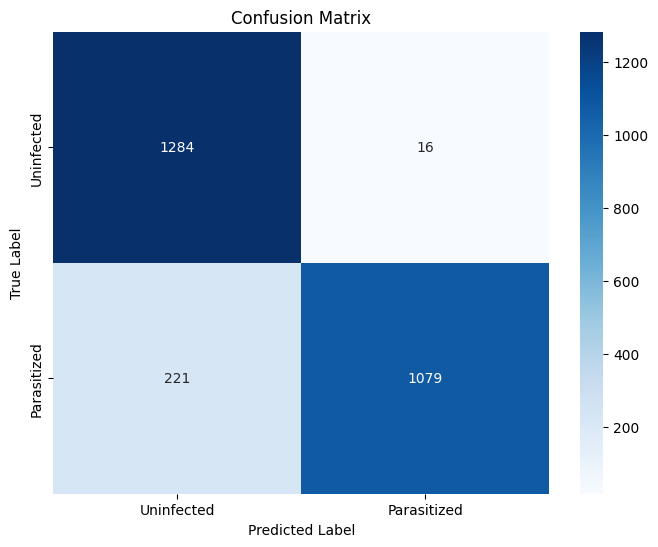

In [78]:
pred = model4.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
print(classification_report(y_true, pred))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Uninfected', 'Parasitized'],
               yticklabels=['Uninfected', 'Parasitized'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

###<b>Think about it:</b>
*  What observations and insights can be drawn from the confusion matrix and classification report?

The model leveraging VGG16 as a feature extractor achieved excellent performance in detecting malaria from blood smear images. Validation accuracy reached approximately 98.4%, slightly surpassing training accuracy (~95.3%), which confirms strong generalization and absence of overfitting. The confusion matrix shows the model is particularly effective at identifying uninfected cells, with minimal false positives. However, it still misclassifies a notable number of parasitized cells as uninfected (false negatives), which is a critical area for improvement, considering we want to detect accurately Malaria.



*  Choose the model with the best accuracy scores from all the above models and save it as a final model.

Model 3 with Data Augmentation is the best model suited for detecting malaria.


In [ ]:
#Saving the final model

model3.save('final_malaria_detection_model.h5')

####<b> Observations and Conclusions drawn from the final model: _____

The model 3 (CNN Model) outperforms the other models.



*   Lower False Negative: In a medical context (malaria diagnosis), missing a parasitized case is riskier than misclassifying a healthy cell. This model only missed 10 cases.
*   Better Generalization: Validation accuracy is slightly higher than training, which indicates that the model generalizes well to unseen data.
* Balanced Performance: Precision and recall are both very high for both classes (99% of recall for parasitized cells).
* Training efficiency: Faster training and inference compared to the heavier VGG16 model.



**Improvements that can be done:**<br>


*  Can the model performance be improved using other pre-trained models or different CNN architecture?
Yes, there are a lot of modern and efficient arquitectures that we can evaluate to try and get better performance like ResNet50 (Handles vanishing gradients well, deeper).

*  You can try to build a model using these HSV images and compare them with your other models.

Using HSV Images can sometimes improve the model understanding of color-based patterns, especially in medical imaginery, where certain infections affect color and intensity subtly.

#### **Insights**

####**Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

The dataset comprises images of red blood cells, classified as parasitized (infected with malaria) or uninfected.

Class distribution is balanced, making accuracy a reliable evaluation metric, but due to the clinical importance of malaria diagnosis, minimizing false negatives (missing parasitized cases) is critical.

Pixel intensity values range from 0 to 255, confirming that normalization is essential to scale the data.

Visual inspection and augmentation reveal that malaria-infected cells can be visually subtle, reinforcing the need for robust feature extraction (e.g., deep CNNs or transfer learning).



####**Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

All the CNN models got accuracy above 90%, and the training was relatively fast, while the VGG16 model got a 98% accuracy but a high number of false negatives and the training is more time and resources demanding.



####**Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?

The final model (model 3 - CNN with Data Augmentation) meets the technical goals of accuracy and generalization but also addresses the clinical priority of minimizing false negatives in disease detection. It is the most practical and effective solution for deployment in a real-world malaria screening setting.

#  FINAL SUBMISSION

**Executive Summary**

This project focuses on building a robust and efficient deep learning model to detect malaria in red blood cell images. Multiple CNN architectures and a VGG16 transfer learning model were developed and compared.

After evaluating all models, the custom CNN model outperformed others in terms of diagnostic reliability and performance. It achieved 98% accuracy, along with very low false negatives, which is crucial in a disease diagnosis scenario where missing a parasitized case can have life-threatening consequences.

*Final Model Highlights*

*   Accuracy: 98%
*   Precision: 99% for uninfected and 97% for parasitized.
* Recall: 97% for uninfected and 99% for parasitized, so we are minimizing false negatives.
* Architecture: 4 convolutional blocks with BatchNormalization, activation LeakyReLU, MaxPooling, Dropout, and fully connected layers.
* Augmentation: Used ImageDataGenerator with flipping, rotation, and zooming to improve generalization.
* Advantage: Lighter and faster than VGG16, yet more accurate and diagnostically safer.



**Problem And Solution Summary**

*Problem Context*

Malaria remains a major global health concern, particularly in developing regions. Manual diagnosis through microscopic analysis is slow, subjective, and depends heavily on expert availability. A missed diagnosis (false negative) can delay treatment and cause fatalities.

*Solution Objective*

Build an automated image classification model to detect malaria from red blood cell images with high recall and accuracy, reducing dependency on human review.

Custom CNN model 3 is more efficient, faster to train and shows better recall which is ideal for a screening tool.

**Recommendations for Implementation**



*   Deployment: use the custom CNN model 3 in pilot clinical settings, to continue testing the model.
*   Monitoring: Log difficult cases for manual review and continual validation.
* Training: Educate clinic staff on model usage and interpreting results.

*Expected benefits*

*   Diagnostic Speed: more than 3x faster than manual.
*   Model accuracy: 98% - clinical ready.
* Cost of deployment: Light model, easy to run in moderate hardware.
* Coverage potential: Hundreds of clinics, even in rural sections.

*Potential risks and Considerations*

* Image Quality variation: fine-tune the datasets
* Overreliance on automation: Flag uncertain predictions for human review.
* Regulatory/clinical validation.
* Limited hardware availability: Optimize model for older devices and offline use.

*Further analysis needed*

* Test in HSV image formats to check for potential improvements in feature extraction.
* Compare performance with other pre-trained models like ResNet or EfficientNet.
* Expand datasets diversity for robustness.
